<a href="https://colab.research.google.com/github/meri-crush/Experiment_Learning_AI/blob/main/Agentic_AML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

In [3]:
np.random.seed(42)

In [4]:
n = 10000

In [6]:
data = pd.DataFrame({"transaction_id": range(n)})

In [8]:
channels = ["WB","UP","CR","NE","RT"]

txn_ids = []

for i in range(n):

    channel = np.random.choice(channels)

    seq = str(i).zfill(8)

    txn_id = f"TXN20260315{channel}{seq}"

    txn_ids.append(txn_id)

In [24]:
countries = ["IN","US","UK","SG","AE","KY"]

banks = ["BANK_A","BANK_B","BANK_C","BANK_D","BANK_E"]

customer_types = ["individual","business"]

transaction_types = ["SWIFT","WIRE","RTGS","NEFT","CARD"]

channels = ["mobile","web","branch","atm"]

networks = ["SWIFT","SEPA","LOCAL"]

currencies = ["USD","EUR","GBP","AED","SGD","INR"]

swift_types = ["MT103","MT202"]

purposes = ["trade","remittance","salary","investment","loan"]

In [63]:
customers = pd.read_parquet("customers.parquet")
accounts = pd.read_parquet("accounts.parquet")

n_txn = 10000

# pick random accounts
sender_accounts = np.random.choice(accounts["account_id"], n_txn)
receiver_accounts = np.random.choice(accounts["account_id"], n_txn)

# map accounts → customers
account_customer_map = accounts.set_index("account_id")["customer_id"]

sender_customer = pd.Series(sender_accounts).map(account_customer_map)
receiver_customer = pd.Series(receiver_accounts).map(account_customer_map)

# generate transaction IDs
txn_ids = [f"TXN{i:08d}" for i in range(n_txn)]

transactions = pd.DataFrame({

    "transaction_id": txn_ids,

    "transaction_timestamp": pd.date_range(
        "2026-01-01", periods=n_txn, freq="min"
    ),

    "sender_account": sender_accounts,
    "receiver_account": receiver_accounts,

    "sender_customer_id": sender_customer.values,
    "receiver_customer_id": receiver_customer.values,

    "amount": np.round(np.random.exponential(2000,n_txn),2),

    "currency": np.random.choice(["USD","EUR","GBP","AED","SGD","INR"],n_txn),

    "channel": np.random.choice(["mobile","web","branch","atm"],n_txn)

})

transactions.to_parquet("transactions.parquet", index=False)

In [26]:
data.head(1)

,transaction_id,transaction_timestamp,sender_account,sender_customer_id,sender_country,sender_bank,sender_bank_country,sender_customer_type,receiver_account,receiver_customer_id,...,fx_rate,amount,intermediary_bank,intermediary_country,swift_message_type,payment_purpose,pep_flag,sanction_match_flag,high_risk_country_flag,offshore_flag
0,TXN20260315NE00000000,2026-01-01,7387087517,272584,IN,BANK_C,US,business,6118329797,160593,...,55.39,48.13,BANK_E,KY,MT103,remittance,0,0,1,0


In [27]:
ountries = ["IN","US","UK","SG","AE","KY"]

cities = ["Mumbai","Delhi","London","Dubai","Singapore","New York"]

customer_types = ["individual","business"]

risk_levels = ["LOW","MEDIUM","HIGH"]

industries = [
    "retail",
    "technology",
    "finance",
    "construction",
    "trading",
    "consulting"
]

kyc_levels = ["basic","standard","enhanced"]

In [29]:
np.random.seed(42)

n_customers = 3000

In [38]:
import pandas as pd
import numpy as np

np.random.seed(42)

n_customers = 3000

# ---------------------------
# STATIC LISTS
# ---------------------------

countries = ["IN","US","UK","SG","AE","KY"]

cities = ["Mumbai","Delhi","London","Dubai","Singapore","New York"]

customer_types = ["individual","business"]

risk_levels = ["LOW","MEDIUM","HIGH"]

industries = [
    "retail",
    "technology",
    "finance",
    "construction",
    "trading",
    "consulting"
]

kyc_levels = ["basic","standard","enhanced"]

# name pools
first_names = [
    "James","John","Robert","Michael","William","David","Richard",
    "Joseph","Thomas","Charles","Daniel","Matthew","Anthony"
]

last_names = [
    "Smith","Johnson","Williams","Brown","Jones","Garcia","Miller",
    "Davis","Rodriguez","Martinez","Hernandez","Lopez","Wilson"
]

popular_companies = [
    "Apple Inc",
    "Microsoft Corporation",
    "Amazon.com Inc",
    "Alphabet Inc",
    "Meta Platforms Inc",
    "Tesla Inc",
    "Samsung Electronics",
    "Toyota Motor Corporation",
    "Alibaba Group",
    "Tencent Holdings",
    "Reliance Industries",
    "Tata Consultancy Services",
    "Infosys Ltd",
    "Walmart Inc",
    "JPMorgan Chase",
    "Goldman Sachs",
    "HSBC Holdings",
    "Siemens AG",
    "Shell PLC",
    "BP PLC"
]

# ---------------------------
# CUSTOMER IDS
# ---------------------------

customer_ids = np.arange(100000,100000+n_customers)

customer_type = np.random.choice(customer_types,n_customers,p=[0.85,0.15])

# ---------------------------
# GENERATE NAMES
# ---------------------------

names = []

for ctype in customer_type:

    if ctype == "individual":

        name = f"{np.random.choice(first_names)} {np.random.choice(last_names)}"

    else:

        name = np.random.choice(popular_companies)

    names.append(name)


# ---------------------------
# CUSTOMER DATAFRAME
# ---------------------------

customers = pd.DataFrame({

    "customer_id": customer_ids,

    "customer_name": names,

    "customer_type": customer_type,

    "country": np.random.choice(countries,n_customers),

    "city": np.random.choice(cities,n_customers),

    "date_of_birth": pd.to_datetime(
        np.random.randint(
            pd.Timestamp("1960-01-01").value,
            pd.Timestamp("2000-01-01").value,
            n_customers
        )
    ),

    "industry": np.random.choice(industries,n_customers),

    "annual_income": np.round(np.random.lognormal(10,1,n_customers),2),

    "expected_txn_volume": np.round(np.random.lognormal(8,1,n_customers),2),

    "risk_rating": np.random.choice(risk_levels,n_customers,p=[0.7,0.2,0.1]),

    "pep_flag": np.random.choice([0,1],n_customers,p=[0.98,0.02]),

    "sanction_flag": np.random.choice([0,1],n_customers,p=[0.995,0.005]),

    "kyc_level": np.random.choice(kyc_levels,n_customers)

})





In [39]:
customers.head(5)

,customer_id,customer_name,customer_type,country,city,date_of_birth,industry,annual_income,expected_txn_volume,risk_rating,pep_flag,sanction_flag,kyc_level
0,100000,Robert Rodriguez,individual,SG,Singapore,1999-10-03 08:15:05.455499630,consulting,15783.98,241.09,LOW,0,0,basic
1,100001,Meta Platforms Inc,business,AE,Mumbai,1987-01-24 06:34:55.012272456,trading,11324.20,7422.58,LOW,0,0,standard
2,100002,Joseph Miller,individual,AE,Singapore,1993-02-28 16:24:45.033455060,construction,8496.28,6288.44,LOW,0,0,basic
3,100003,Joseph Miller,individual,SG,Singapore,1967-07-13 11:41:20.832870260,technology,91596.59,1099.40,LOW,0,0,basic
4,100004,Robert Johnson,individual,IN,New York,1973-09-26 22:56:56.037905406,trading,6632.92,4218.97,MEDIUM,0,0,basic


In [41]:
# save customers table
customers.to_parquet(
    "customers.parquet",
    index=False,
    engine="pyarrow"
)

# save transactions table


In [43]:
# save transactions table
data.to_parquet(
    "transactions.parquet",
    index=False,
    engine="pyarrow"
)

In [44]:
customers_parquet = pd.read_parquet("customers.parquet")

transactions_parquet = pd.read_parquet("transactions.parquet")



In [45]:
customers_parquet.head(1)

,customer_id,customer_name,customer_type,country,city,date_of_birth,industry,annual_income,expected_txn_volume,risk_rating,pep_flag,sanction_flag,kyc_level
0,100000,Robert Rodriguez,individual,SG,Singapore,1999-10-03 08:15:05.455499630,consulting,15783.98,241.09,LOW,0,0,basic


In [46]:
transactions_parquet.head(1)

,transaction_id,transaction_timestamp,sender_account,sender_customer_id,sender_country,sender_bank,sender_bank_country,sender_customer_type,receiver_account,receiver_customer_id,...,fx_rate,amount,intermediary_bank,intermediary_country,swift_message_type,payment_purpose,pep_flag,sanction_match_flag,high_risk_country_flag,offshore_flag
0,TXN20260315NE00000000,2026-01-01,7387087517,272584,IN,BANK_C,US,business,6118329797,160593,...,55.39,48.13,BANK_E,KY,MT103,remittance,0,0,1,0


In [47]:
import pandas as pd
import numpy as np

np.random.seed(42)

# load customers
customers = pd.read_parquet("customers.parquet")

# each customer has 1–3 accounts
accounts_per_customer = np.random.randint(1,4,len(customers))

account_rows = []

account_counter = 900000

banks = [
    "Global Bank",
    "Prime Bank",
    "Vertex Financial",
    "Summit Bank",
    "BlueSky Bank"
]

account_types = ["savings","current","corporate"]

statuses = ["active","active","active","dormant","closed"]

for idx, row in customers.iterrows():

    customer_id = row["customer_id"]

    num_accounts = accounts_per_customer[idx]

    for _ in range(num_accounts):

        account_id = f"A{account_counter}"

        account_counter += 1

        account_rows.append({

            "account_id": account_id,

            "customer_id": customer_id,

            "bank": np.random.choice(banks),

            "account_type": np.random.choice(account_types),

            "open_date": pd.Timestamp("2010-01-01") + pd.to_timedelta(
                np.random.randint(0,5000), unit="D"
            ),

            "balance": np.round(np.random.lognormal(10,1),2),

            "status": np.random.choice(statuses)

        })


accounts = pd.DataFrame(account_rows)


accounts.to_parquet("accounts.parquet", index=False)

In [48]:
accounts.head(1)

,account_id,customer_id,bank,account_type,open_date,balance,status
0,A900000,100000,Summit Bank,corporate,2010-06-12,53440.82,active


In [49]:
customers = pd.read_parquet("customers.parquet")
accounts = pd.read_parquet("accounts.parquet")
transactions = pd.read_parquet("transactions.parquet")


In [50]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   customer_id          3000 non-null   int64         
 1   customer_name        3000 non-null   object        
 2   customer_type        3000 non-null   object        
 3   country              3000 non-null   object        
 4   city                 3000 non-null   object        
 5   date_of_birth        3000 non-null   datetime64[ns]
 6   industry             3000 non-null   object        
 7   annual_income        3000 non-null   float64       
 8   expected_txn_volume  3000 non-null   float64       
 9   risk_rating          3000 non-null   object        
 10  pep_flag             3000 non-null   int64         
 11  sanction_flag        3000 non-null   int64         
 12  kyc_level            3000 non-null   object        
dtypes: datetime64[ns](1), float64(2),

In [52]:
accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5921 entries, 0 to 5920
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   account_id    5921 non-null   object        
 1   customer_id   5921 non-null   int64         
 2   bank          5921 non-null   object        
 3   account_type  5921 non-null   object        
 4   open_date     5921 non-null   datetime64[ns]
 5   balance       5921 non-null   float64       
 6   status        5921 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 323.9+ KB


In [54]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   transaction_id          10000 non-null  object        
 1   transaction_timestamp   10000 non-null  datetime64[ns]
 2   sender_account          10000 non-null  int64         
 3   sender_customer_id      10000 non-null  int64         
 4   sender_country          10000 non-null  object        
 5   sender_bank             10000 non-null  object        
 6   sender_bank_country     10000 non-null  object        
 7   sender_customer_type    10000 non-null  object        
 8   receiver_account        10000 non-null  int64         
 9   receiver_customer_id    10000 non-null  int64         
 10  receiver_country        10000 non-null  object        
 11  receiver_bank           10000 non-null  object        
 12  receiver_bank_country   10000 non-null  object 

In [55]:
invalid_accounts = accounts[
    ~accounts["customer_id"].isin(customers["customer_id"])
]

In [56]:
invalid_accounts

,account_id,customer_id,bank,account_type,open_date,balance,status


In [60]:
invalid_sender = transactions[
    ~transactions["sender_customer_id"].isin(accounts["customer_id"])
]


In [64]:
mismatch = transactions[
    transactions["sender_customer_id"] !=
    transactions["sender_account"].map(account_customer_map)
]

print("mismatches:", len(mismatch))

mismatches: 0


In [65]:
transactions.sender_account.isin(accounts.account_id).all()

np.True_

In [66]:
(
transactions.sender_account.map(accounts.set_index("account_id").customer_id)
== transactions.sender_customer_id
).all()

np.True_

In [67]:
import pandas as pd
import networkx as nx

customers = pd.read_parquet("customers.parquet")
accounts = pd.read_parquet("accounts.parquet")
transactions = pd.read_parquet("transactions.parquet")

In [68]:
G = nx.DiGraph()

for _, txn in transactions.iterrows():

    sender = txn["sender_account"]
    receiver = txn["receiver_account"]

    G.add_edge(
        sender,
        receiver,
        transaction_id=txn["transaction_id"],
        amount=txn["amount"],
        timestamp=txn["transaction_timestamp"]
    )

In [69]:
print("Number of accounts:", G.number_of_nodes())
print("Number of transactions:", G.number_of_edges())

Number of accounts: 5719
Number of transactions: 9996


In [70]:
degree = dict(G.degree())

suspicious_accounts = sorted(
    degree.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print("Top active accounts:", suspicious_accounts)

Top active accounts: [('A905049', 12), ('A903128', 11), ('A902222', 11), ('A901353', 10), ('A902917', 10), ('A903305', 10), ('A900504', 10), ('A904570', 10), ('A904014', 10), ('A903674', 10)]


In [71]:
paths = list(nx.simple_paths.all_simple_paths(G, source=sender, target=receiver, cutoff=4))

In [72]:
clusters = list(nx.weakly_connected_components(G))

print("Number of clusters:", len(clusters))

Number of clusters: 15


In [73]:
high_degree_accounts = [acc for acc,deg in degree.items() if deg > 20]

print("Potential mule accounts:", high_degree_accounts[:10])

Potential mule accounts: []


In [74]:
pip install matplotlib

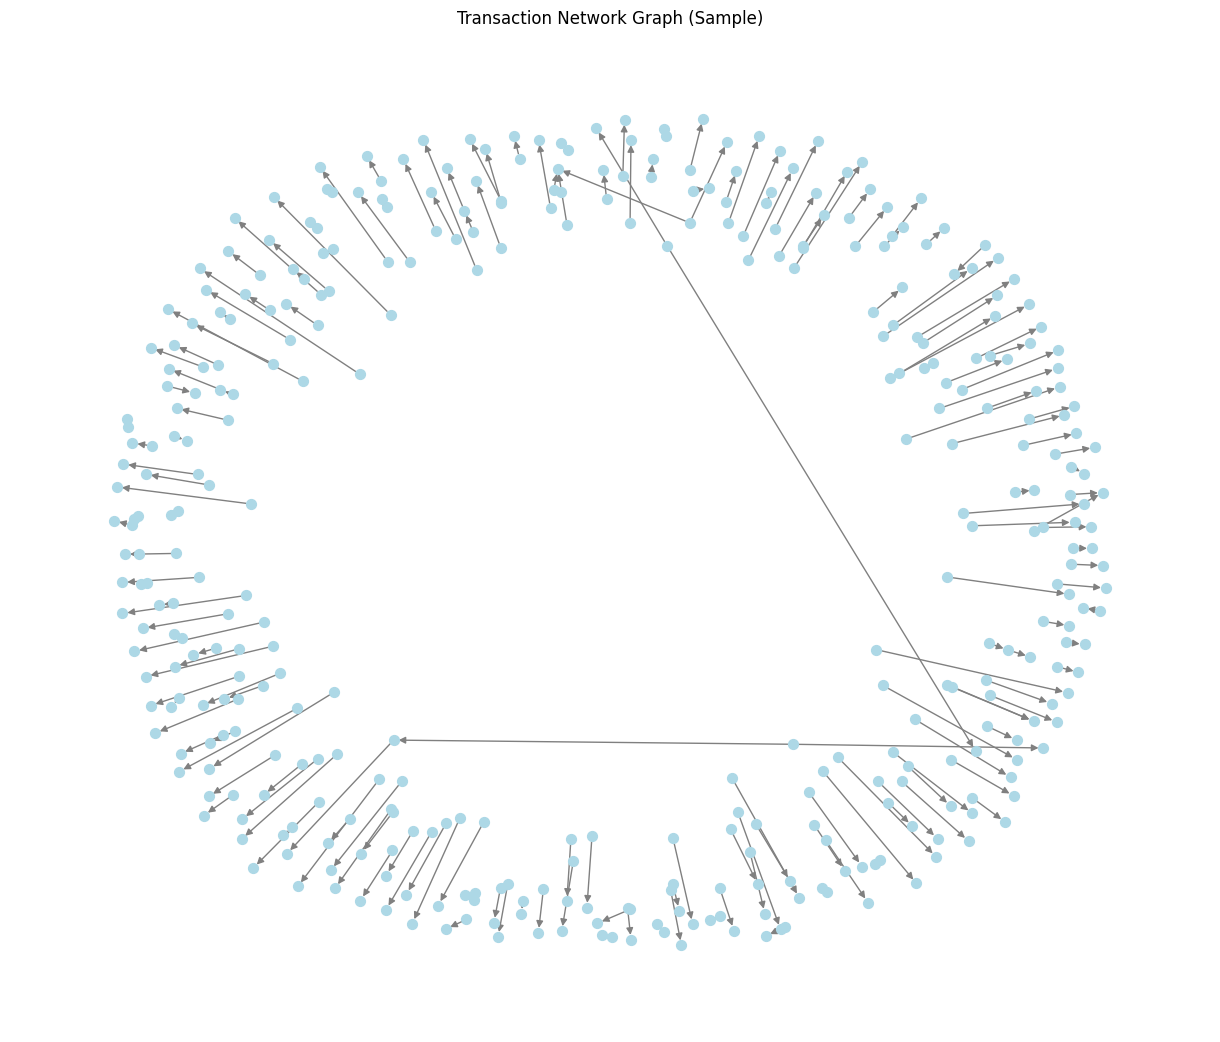

In [75]:
import matplotlib.pyplot as plt
import networkx as nx

# sample subset of transactions for visualization
sample_txn = transactions.sample(200)

G = nx.DiGraph()

for _, txn in sample_txn.iterrows():
    G.add_edge(
        txn["sender_account"],
        txn["receiver_account"],
        weight=txn["amount"]
    )

plt.figure(figsize=(12,10))

pos = nx.spring_layout(G, k=0.5)

nx.draw(
    G,
    pos,
    node_size=50,
    node_color="lightblue",
    edge_color="gray",
    arrows=True
)

plt.title("Transaction Network Graph (Sample)")
plt.show()

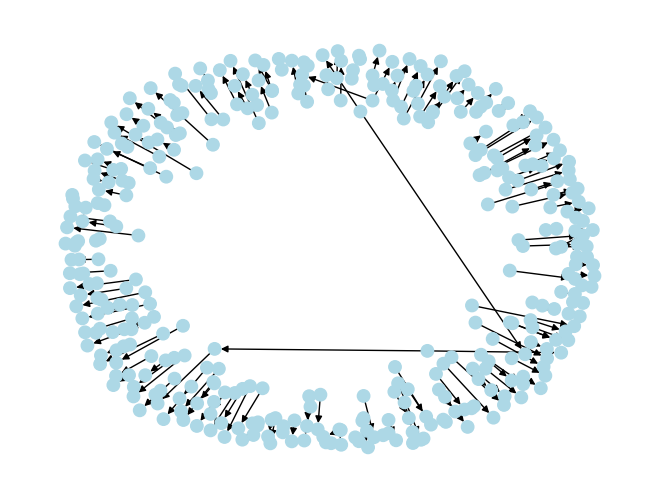

In [76]:
node_colors = []

for node in G.nodes():
    if node in suspicious_accounts:
        node_colors.append("red")
    else:
        node_colors.append("lightblue")

nx.draw(G, pos, node_color=node_colors, node_size=80)

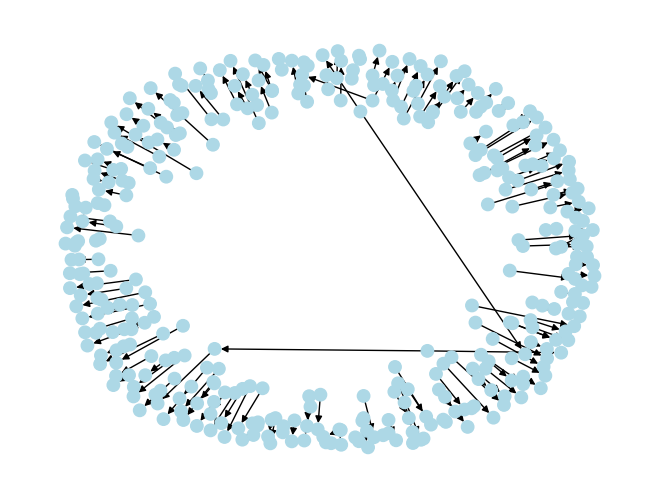

In [77]:
node_colors = []

for node in G.nodes():
    if node in suspicious_accounts:
        node_colors.append("red")
    else:
        node_colors.append("lightblue")

nx.draw(G, pos, node_color=node_colors, node_size=80)

In [78]:
degree = dict(G.degree())

# top 10 most connected accounts
top_accounts = sorted(degree.items(), key=lambda x: x[1], reverse=True)[:10]

print("Potential mule accounts:")
for acc, deg in top_accounts:
    print(acc, deg)

Potential mule accounts:
A905615 3
A901776 2
A904971 2
A905063 2
A900229 2
A904446 2
A902434 2
A902301 2
A903116 2
A900976 2


In [79]:
from networkx.algorithms.community import greedy_modularity_communities

communities = list(greedy_modularity_communities(G))

print("Number of communities:", len(communities))
print("Largest community size:", len(max(communities, key=len)))

Number of communities: 186
Largest community size: 6


In [80]:
cycles = list(nx.simple_cycles(G))

print("Number of cycles:", len(cycles))

print("Example cycles:")
for c in cycles[:5]:
    print(c)

Number of cycles: 0
Example cycles:


In [81]:
centrality = nx.betweenness_centrality(G)

top_intermediaries = sorted(
    centrality.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print("Key intermediaries:")
print(top_intermediaries)

Key intermediaries:
[('A904971', 6.764069264069264e-06), ('A905063', 6.764069264069264e-06), ('A900229', 6.764069264069264e-06), ('A902434', 6.764069264069264e-06), ('A903116', 6.764069264069264e-06), ('A901986', 6.764069264069264e-06), ('A900003', 0.0), ('A904512', 0.0), ('A900898', 0.0), ('A904736', 0.0)]


In [82]:
smurf_accounts = np.random.choice(accounts.account_id, 10)

smurf_txns = []

for hub in smurf_accounts:

    senders = np.random.choice(accounts.account_id, 20)

    for s in senders:

        smurf_txns.append({
            "sender_account": s,
            "receiver_account": hub,
            "amount": np.random.uniform(9000, 9999)
        })

smurf_df = pd.DataFrame(smurf_txns)

In [83]:
layering_txns = []

for _ in range(50):

    chain = np.random.choice(accounts.account_id, 5)

    for i in range(len(chain)-1):

        layering_txns.append({
            "sender_account": chain[i],
            "receiver_account": chain[i+1],
            "amount": np.random.uniform(20000, 50000)
        })

layering_df = pd.DataFrame(layering_txns)

In [84]:
mule_accounts = np.random.choice(accounts.account_id, 5)

mule_txns = []

for mule in mule_accounts:

    senders = np.random.choice(accounts.account_id, 30)
    receivers = np.random.choice(accounts.account_id, 30)

    for s in senders:

        mule_txns.append({
            "sender_account": s,
            "receiver_account": mule,
            "amount": np.random.uniform(5000,15000)
        })

    for r in receivers:

        mule_txns.append({
            "sender_account": mule,
            "receiver_account": r,
            "amount": np.random.uniform(5000,15000)
        })

mule_df = pd.DataFrame(mule_txns)

In [85]:
round_txns = []

for _ in range(30):

    chain = np.random.choice(accounts.account_id, 4)

    round_txns.append({
        "sender_account": chain[0],
        "receiver_account": chain[1],
        "amount": 30000
    })

    round_txns.append({
        "sender_account": chain[1],
        "receiver_account": chain[2],
        "amount": 29500
    })

    round_txns.append({
        "sender_account": chain[2],
        "receiver_account": chain[3],
        "amount": 29000
    })

    round_txns.append({
        "sender_account": chain[3],
        "receiver_account": chain[0],
        "amount": 28500
    })

round_df = pd.DataFrame(round_txns)

In [86]:
round_txns = []

for _ in range(30):

    chain = np.random.choice(accounts.account_id, 4)

    round_txns.append({
        "sender_account": chain[0],
        "receiver_account": chain[1],
        "amount": 30000
    })

    round_txns.append({
        "sender_account": chain[1],
        "receiver_account": chain[2],
        "amount": 29500
    })

    round_txns.append({
        "sender_account": chain[2],
        "receiver_account": chain[3],
        "amount": 29000
    })

    round_txns.append({
        "sender_account": chain[3],
        "receiver_account": chain[0],
        "amount": 28500
    })

round_df = pd.DataFrame(round_txns)

In [87]:
def detect_smurfing(transactions, threshold=10000, min_txn=10):

    small_txn = transactions[transactions["amount"] < threshold]

    counts = small_txn.groupby("receiver_account").size()

    suspicious = counts[counts >= min_txn]

    return suspicious.sort_values(ascending=False)

In [89]:
smurf_accounts = detect_smurfing(transactions)

print("Potential smurfing accounts:")
print(smurf_accounts.head())

Potential smurfing accounts:
Series([], dtype: int64)


In [90]:
def detect_mule_accounts(G, degree_threshold=20):

    degree = dict(G.degree())

    mule_accounts = {
        acc:deg for acc,deg in degree.items()
        if deg > degree_threshold
    }

    return mule_accounts

In [91]:
mule_accounts = detect_mule_accounts(G)

print("Potential mule accounts:")
print(list(mule_accounts.items())[:10])

Potential mule accounts:
[]


In [92]:
def detect_layering(G, depth=4):

    chains = []

    for node in G.nodes():

        paths = nx.single_source_shortest_path(G, node, cutoff=depth)

        for p in paths.values():

            if len(p) >= depth:
                chains.append(p)

    return chains

In [93]:
layering_chains = detect_layering(G)

print("Example layering chains:")
for c in layering_chains[:5]:
    print(c)

Example layering chains:


In [94]:
def detect_cycles(G):

    cycles = list(nx.simple_cycles(G))

    return cycles

In [95]:
cycles = detect_cycles(G)

print("Circular money flows detected:", len(cycles))

print("Example cycles:")
for c in cycles[:5]:
    print(c)

Circular money flows detected: 0
Example cycles:


In [96]:
def detect_intermediaries(G):

    centrality = nx.betweenness_centrality(G)

    top = sorted(
        centrality.items(),
        key=lambda x: x[1],
        reverse=True
    )[:10]

    return top

In [97]:
intermediaries = detect_intermediaries(G)

print("Top intermediaries:")
print(intermediaries)

Top intermediaries:
[('A904971', 6.764069264069264e-06), ('A905063', 6.764069264069264e-06), ('A900229', 6.764069264069264e-06), ('A902434', 6.764069264069264e-06), ('A903116', 6.764069264069264e-06), ('A901986', 6.764069264069264e-06), ('A900003', 0.0), ('A904512', 0.0), ('A900898', 0.0), ('A904736', 0.0)]


In [98]:
class AMLAgent:

    def __init__(self, name):
        self.name = name

    def run(self, data):
        raise NotImplementedError

In [100]:
class SmurfingAgent(AMLAgent):

    def run(self, transactions):

        small_txn = transactions[transactions["amount"] < 10000]

        counts = small_txn.groupby("receiver_account").size()

        suspicious = counts[counts > 10]

        return suspicious

In [101]:
class MuleAgent(AMLAgent):

    def run(self, graph):

        degree = dict(graph.degree())

        mule_accounts = {
            acc:deg for acc,deg in degree.items()
            if deg > 20
        }

        return mule_accounts

In [102]:
class LayeringAgent(AMLAgent):

    def run(self, graph):

        import networkx as nx

        cycles = list(nx.simple_cycles(graph))

        return cycles

In [103]:
class InvestigationAgent(AMLAgent):

    def run(self, results):

        alerts = []

        for key,value in results.items():

            if len(value) > 0:

                alerts.append({
                    "agent": key,
                    "alerts_found": len(value)
                })

        return alerts

In [104]:
class RiskScoringAgent(AMLAgent):

    def run(self, alerts):

        score = 0

        for a in alerts:

            score += a["alerts_found"]

        if score > 20:
            risk = "HIGH"
        elif score > 5:
            risk = "MEDIUM"
        else:
            risk = "LOW"

        return risk

In [105]:
class SARAgent(AMLAgent):

    def run(self, risk):

        report = f"""
        Suspicious Activity Report

        Risk Level: {risk}

        Recommendation:
        Investigate account network and transaction behavior.
        """

        return report

In [106]:
def run_aml_agents(transactions, graph):

    smurf = SmurfingAgent("smurf")
    mule = MuleAgent("mule")
    layering = LayeringAgent("layering")

    results = {}

    results["smurf"] = smurf.run(transactions)
    results["mule"] = mule.run(graph)
    results["layering"] = layering.run(graph)

    investigator = InvestigationAgent("investigator")

    alerts = investigator.run(results)

    risk_agent = RiskScoringAgent("risk")

    risk = risk_agent.run(alerts)

    sar_agent = SARAgent("sar")

    report = sar_agent.run(risk)

    return report

In [108]:
report = run_aml_agents(transactions, G)

print(report)


        Suspicious Activity Report

        Risk Level: LOW

        Recommendation:
        Investigate account network and transaction behavior.
        


In [1]:
def run_aml_agents(transactions, graph):

    smurf = SmurfingAgent("smurf")
    mule = MuleAgent("mule")
    layering = LayeringAgent("layering")

    results = {}

    results["smurf"] = smurf.run(transactions)
    results["mule"] = mule.run(graph)
    results["layering"] = layering.run(graph)

    investigator = InvestigationAgent("investigator")

    alerts = investigator.run(results)

    risk_agent = RiskScoringAgent("risk")

    risk = risk_agent.run(alerts)

    sar_agent = SARAgent("sar")

    report = sar_agent.run(risk)

    return report


In [3]:
pip install openai

In [33]:
class LLMInvestigationAgent:

    def __init__(self, client):
        self.client = client

    def run(self, alerts):

        prompt = f"""
        You are a financial crime investigator.

        The AML system detected the following alerts:

        {alerts}

        Explain what suspicious behavior this represents
        and whether it could indicate money laundering.
        """

        response = self.client.responses.create(
            model="gpt-4.1-mini",
            input=prompt,
            max_output_tokens=200 # Further reduced to limit token usage
        )

        return response.output_text

In [34]:
alerts = [
    {"agent": "smurfing", "alerts_found": 12},
    {"agent": "mule", "alerts_found": 3},
    {"agent": "layering", "alerts_found": 2}
]

In [35]:
import os
from openai import OpenAI

# Set your OpenRouter API key here
os.environ["OPENAI_API_KEY"] = "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" # Replace with your actual OpenRouter API key

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENAI_API_KEY")
)

In [36]:
investigator = LLMInvestigationAgent(client)

analysis = investigator.run(alerts)

print(analysis)

The alerts detected by the AML (Anti-Money Laundering) system correspond to three types of suspicious behaviors often associated with money laundering:

1. **Smurfing (12 alerts found):**
   - **Suspicious behavior:** Smurfing involves breaking down a large sum of money into many smaller transactions to avoid detection by reporting thresholds. These individual transactions are typically structured to appear legitimate and are spread out across multiple accounts or locations.
   - **Money laundering indication:** This is a classic money laundering technique used to evade regulatory scrutiny by camouflaging the origin of illicit money. A high number of smurfing alerts strongly suggests an attempt to move illegal funds in a way that avoids triggering automatic reporting and investigation.

2. **Mule (3 alerts found):**
   - **Suspicious behavior:** A mule is an individual who transfers illegally acquired money on behalf of others, often without fully understanding that they are involved i

In [37]:
class RiskScoringAgent:

    def run(self, alerts):

        score = 0

        for a in alerts:

            if a["agent"] == "smurf":
                score += 25 * a["alerts_found"]

            elif a["agent"] == "mule":
                score += 25 * a["alerts_found"]

            elif a["agent"] == "layering":
                score += 20 * a["alerts_found"]

        # cap score at 100
        score = min(score, 100)

        return score

In [38]:
def sar_decision(score):

    if score >= 70:
        return "SAR REQUIRED"

    elif score >= 40:
        return "REVIEW REQUIRED"

    else:
        return "LOW RISK"

In [39]:
class CaseNarrativeAgent:

    def __init__(self, client):
        self.client = client

    def run(self, alerts, score):

        prompt = f"""
        You are an AML investigator.

        Alerts detected:
        {alerts}

        Risk score: {score}/100

        Write a short AML investigation case summary
        explaining why this activity may be suspicious.
        """

        response = self.client.responses.create(
            model="gpt-4.1-mini",
            input=prompt
        )

        return response.output_text

In [40]:
class CaseNarrativeAgent:

    def __init__(self, client):
        self.client = client

    def run(self, alerts, score):

        prompt = f"""
        You are an AML investigator.

        Alerts detected:
        {alerts}

        Risk score: {score}/100

        Write a short AML investigation case summary
        explaining why this activity may be suspicious.
        """

        response = self.client.responses.create(
            model="gpt-4.1-mini",
            input=prompt
        )

        return response.output_text

In [41]:
def build_case(alerts):

    risk_agent = RiskScoringAgent()

    score = risk_agent.run(alerts)

    decision = sar_decision(score)

    narrative_agent = CaseNarrativeAgent(client)

    narrative = narrative_agent.run(alerts, score)

    case = {
        "risk_score": score,
        "decision": decision,
        "alerts": alerts,
        "narrative": narrative
    }

    return case

In [42]:
alerts = [
    {"agent": "smurf", "alerts_found": 2},
    {"agent": "mule", "alerts_found": 1},
    {"agent": "layering", "alerts_found": 1}
]

case = build_case(alerts)

APIStatusError: Error code: 402 - {'error': {'message': 'This request requires more credits, or fewer max_tokens. You requested up to 65536 tokens, but can only afford 24944. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account', 'code': 402, 'metadata': {'provider_name': None}}, 'user_id': 'user_3ApLleIRkpioDMu3gY5ZAkGJVUZ'}